# Testing the KMRF Class for Bitcoin Trading

This notebook tests the `KMRF` class implementation for Bitcoin trading using the KAMA+MSR+Random Forest approach described in "Improving Portfolio Performance Using a Novel Method for Predicting Financial Regimes" by Piotr Pomorski and Denise Gorse.

We will:
1. Load the Bitcoin price and on-chain data.
2. Initialize the KMRF model.
3. Run the full pipeline (regime detection, feature extraction, feature selection, RF training, prediction, trading, and evaluation).
4. Inspect the results (portfolio, performance metrics, MCC scores).
5. Save the model for future use.

In [1]:
# Import necessary libraries
import pandas as pd
from KMRF import KMRF  # Assuming the KMRF class is in kmrf.py
import warnings

warnings.filterwarnings('ignore')

## 1. Initialize the KMRF Model

We initialize the `KMRF` model with the paths to the Bitcoin price and on-chain data. The `init_date` is set to `'2018-01-01'` to ensure all on-chain features are available (some start in 2018). The `train_test_split` is set to 0.85, meaning 85% of the data will be used for training, and 15% for testing.

In [2]:
# Initialize the KMRF model
kmrf = KMRF(
    price_data_path='/Users/valter.rebelo/MissionControl/data/micro/candleData/bitcoin_candles.csv',
    onchain_data_path='/Users/valter.rebelo/MissionControl/data/onchainData',
    train_test_split=0.85,
    init_date='2015-01-01',
    embargo_pct=0.01
)

# The load_data method is called automatically during initialization
# Check the loaded data
print("First few rows of the combined data:")
print(kmrf.data.head())
print("\nData columns:")
print(kmrf.data.columns.tolist())

Loading on-chain data for bitcoin...
Loaded 29 on-chain metrics
Data loaded successfully: 3731 records
Training set: 3171 records
Test set: 560 records
First few rows of the combined data:
              open    high     low   close  price_drawdown_relative      mvrv  \
date                                                                            
2015-01-01  313.99  313.99  313.99  313.99                -0.754347  0.984037   
2015-01-02  314.45  314.45  314.45  314.45                -0.752510  0.989531   
2015-01-03  286.57  286.57  286.57  286.57                -0.780266  0.906580   
2015-01-04  260.94  260.94  260.94  260.94                -0.793188  0.830200   
2015-01-05  273.22  273.22  273.22  273.22                -0.783760  0.873018   

            utxo_loss_count  mvrv_sth  exchanges_net_pit  entity_adj_nupl  \
date                                                                        
2015-01-01         10150049  0.829138                NaN         0.008090   
2015-01-02  

In [3]:
kmrf.data

,open,high,low,close,price_drawdown_relative,mvrv,utxo_loss_count,mvrv_sth,exchanges_net_pit,entity_adj_nupl,...,lth_realized_supply_density_10pct,net_realized_profit_loss,relative_unrealized_loss,relative_unrealized_profit,realized_price,sth_realized_supply_density_5pct,sth_realized_supply_density_15pct,supply_active_3m_6m,sth_sopr,entity_adj_dormancy_flow
date,,,,,,,,,,,,,,,,,,,,,
2015-01-01,313.99,313.99,313.99,313.99,-0.754347,0.984037,10150049,0.829138,NaN,0.008090,...,0.008999,-5.561998e+05,0.381084,0.364861,319.119672,0.262457,0.476430,1.047080e+06,0.991883,292958.711541
2015-01-02,314.45,314.45,314.45,314.45,-0.752510,0.989531,10018944,0.835331,NaN,0.013594,...,0.009384,-1.249081e+06,0.375770,0.365190,319.027194,0.282606,0.492909,1.050301e+06,0.988247,295203.011128
2015-01-03,286.57,286.57,286.57,286.57,-0.780266,0.906580,10550198,0.769056,NaN,-0.076427,...,0.003781,-8.357621e+06,0.462305,0.359259,318.411967,0.041447,0.306631,1.072252e+06,0.931556,270291.621327
2015-01-04,260.94,260.94,260.94,260.94,-0.793188,0.830200,10568143,0.707971,NaN,-0.175165,...,0.004120,-8.679021e+06,0.557663,0.353134,317.764355,0.026852,0.072697,1.082786e+06,0.924866,248099.894777
2015-01-05,273.22,273.22,273.22,273.22,-0.783760,0.873018,10429863,0.747630,NaN,-0.117739,...,0.003636,-9.465166e+06,0.501804,0.356353,317.060915,0.078041,0.243571,1.081498e+06,0.921622,261442.767960
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-03-15,83955.00,84663.00,83689.00,84392.00,-0.226838,1.936556,30207428,0.905850,-2537.246091,0.470689,...,0.000000,1.218524e+08,0.031853,0.515472,43571.615387,0.177478,0.504607,2.618042e+06,1.002696,167216.855643
2025-03-16,84345.00,84693.00,82061.00,82611.00,-0.243147,1.895501,32461838,0.886351,-808.224579,0.459177,...,0.000000,7.617444e+07,0.037269,0.509704,43576.370952,0.160595,0.404437,2.697522e+06,0.991655,163670.804731
2025-03-17,82570.00,84584.00,82570.00,84075.00,-0.229952,1.928639,30842991,0.902390,-2440.785841,0.468290,...,0.000000,-5.919987e+07,0.032551,0.514051,43574.270043,0.182179,0.479997,2.769282e+06,0.983236,166343.647763


## 2. Run the KMRF Pipeline

The `run_pipeline` method executes the entire KMRF workflow:
- Detects regimes using KAMA+MSR.
- Reclassifies regimes into `Bullish`, `Bearish`, `Other`.
- Extracts features (technical, on-chain, MSR probabilities).
- Selects features using BorutaShap with PGTS cross-validation.
- Trains the Random Forest classifier with Optuna hyperparameter optimization.
- Predicts regimes on the test set.
- Implements a contrarian trading strategy.
- Evaluates performance with financial metrics and MCC.

This step may take some time due to feature selection and hyperparameter optimization.

In [4]:
# Run the pipeline
portfolio, metrics, mcc_scores = kmrf.run_pipeline()

Markov Switching Regression model fitted successfully.
Training data: 3134 points
Embargo data: 37 points
Test data: 558 points
KAMA calculation completed successfully.
Regime classification completed successfully.
Regime reclassification completed successfully.
Processed 23 on-chain metrics out of 23 total
Columns with NaN values before imputation: ['exchanges_net_pit', 'ssr_oscillator', 'volume', 'btc_hash_rate_ma7', 'btc_hash_rate_ma30', 'btc_hash_rate_std30', 'btc_hash_rate_mom7', 'btc_hash_rate_mom30', 'btc_hash_rate_zscore', 'cdd_account_based_ma7', 'cdd_account_based_ma30', 'cdd_account_based_std30', 'cdd_account_based_mom7', 'cdd_account_based_mom30', 'cdd_account_based_zscore', 'entity_adj_dormancy_flow_ma7', 'entity_adj_dormancy_flow_ma30', 'entity_adj_dormancy_flow_std30', 'entity_adj_dormancy_flow_mom7', 'entity_adj_dormancy_flow_mom30', 'entity_adj_dormancy_flow_zscore', 'entity_adj_nupl_ma7', 'entity_adj_nupl_ma30', 'entity_adj_nupl_std30', 'entity_adj_nupl_mom7', 'entity

Feature Extraction: 100%|██████████| 20/20 [01:24<00:00,  4.20s/it]


Feature extraction completed successfully.
Features after preprocessing: ['open', 'high', 'low', 'close', 'price_drawdown_relative', 'mvrv', 'utxo_loss_count', 'mvrv_sth', 'exchanges_net_pit', 'entity_adj_nupl', 'sth_realized_supply_density_10pct', 'mvrv_lth', 'supply_active_1y_2y', 'realized_profits_to_value_ratio', 'reserve_risk', 'lth_realized_supply_density_5pct', 'lth_realized_supply_density_15pct', 'pct_supply_in_profit', 'cdd_account_based', 'ssr_oscillator', 'utxo_profit_count', 'puell_multiple', 'btc_hash_rate', 'lth_realized_supply_density_10pct', 'net_realized_profit_loss', 'relative_unrealized_loss', 'relative_unrealized_profit', 'realized_price', 'sth_realized_supply_density_5pct', 'sth_realized_supply_density_15pct', 'supply_active_3m_6m', 'sth_sopr', 'entity_adj_dormancy_flow', 'volume', 'volume_adi', 'volume_obv', 'volume_cmf', 'volume_fi', 'volume_em', 'volume_sma_em', 'volume_vpt', 'volume_vwap', 'volume_mfi', 'volume_nvi', 'volatility_bbm', 'volatility_bbh', 'volatil

[I 2025-03-21 20:01:59,752] A new study created in memory with name: no-name-febfd82c-1651-4069-b07f-e533da75a355


Fold 3 selected features: ['volatility_bbp', 'volatility_dcp', 'trend_cci', 'entity_adj_nupl_zscore', 'mvrv_zscore', 'mvrv_lth_zscore', 'relative_unrealized_profit_zscore', 'volatility_bbp__sum_values', 'volatility_bbp__median', 'volatility_bbp__mean', 'volatility_bbp__root_mean_square', 'volatility_bbp__maximum', 'volatility_bbp__absolute_maximum', 'volatility_bbp__minimum', 'volatility_dcp__sum_values', 'volatility_dcp__median', 'volatility_dcp__mean', 'volatility_dcp__root_mean_square', 'volatility_dcp__maximum', 'volatility_dcp__absolute_maximum', 'volatility_dcp__minimum', 'trend_cci__sum_values', 'trend_cci__median', 'trend_cci__mean', 'trend_cci__maximum', 'trend_cci__minimum', 'entity_adj_nupl_zscore__sum_values', 'entity_adj_nupl_zscore__median', 'entity_adj_nupl_zscore__mean', 'entity_adj_nupl_zscore__maximum', 'entity_adj_nupl_zscore__minimum', 'mvrv_zscore__sum_values', 'mvrv_zscore__median', 'mvrv_zscore__mean', 'mvrv_zscore__maximum', 'mvrv_zscore__minimum', 'mvrv_lth_zsc

[I 2025-03-21 20:02:00,667] Trial 0 finished with value: -0.33017211428607335 and parameters: {'n_estimators': 152, 'max_depth': 19, 'min_samples_split': 14, 'min_samples_leaf': 19, 'max_samples': 0.14627201322981423, 'min_weight_fraction_leaf': 0.005652182738460704, 'max_features': 0.3218268900559169}. Best is trial 0 with value: -0.33017211428607335.
[I 2025-03-21 20:02:03,297] Trial 1 finished with value: -0.31054888490491245 and parameters: {'n_estimators': 325, 'max_depth': 16, 'min_samples_split': 95, 'min_samples_leaf': 71, 'max_samples': 0.49242124307137924, 'min_weight_fraction_leaf': 0.030476031446868803, 'max_features': 0.21837964258033038}. Best is trial 0 with value: -0.33017211428607335.
[I 2025-03-21 20:02:07,304] Trial 2 finished with value: -0.3350250838017214 and parameters: {'n_estimators': 162, 'max_depth': 2, 'min_samples_split': 90, 'min_samples_leaf': 45, 'max_samples': 0.6190310189447373, 'min_weight_fraction_leaf': 0.040378581495155316, 'max_features': 0.958515

RF training completed. Best parameters: {'n_estimators': 10, 'max_depth': 1, 'min_samples_split': 62, 'min_samples_leaf': 100, 'max_samples': 0.9956390234367827, 'min_weight_fraction_leaf': 0.04687947409276921, 'max_features': 0.8014607579811558}
MCC Scores: {'Bearish': 0.41494405516156463, 'Bullish': 0.6593997990900671, 'Other': 0.0, 'Avg Bullish & Bearish': 0.5371719271258159}
Trading strategy implemented successfully.
Performance metrics calculated successfully.
Performance Metrics: {'BTC Annual Return': 1.5192916813987356, 'Strategy Annual Return': 0.8944594116232114, 'BTC Volatility': 0.5056106010528535, 'Strategy Volatility': 0.3843336108610001, 'BTC Sharpe Ratio': 3.0048651634974677, 'Strategy Sharpe Ratio': 2.3272994771896385, 'BTC Sortino Ratio': 4.813538481342728, 'Strategy Sortino Ratio': 2.919790053738239, 'BTC Max Drawdown': -0.2623190784973599, 'Strategy Max Drawdown': -0.27869142843386563, 'Information Ratio': -1.8898925016177632, 'Number of Trades': 50, 'Total Trading C

## 3. Inspect the Results

Let’s examine the outputs of the pipeline to verify the implementation.

### 3.1 Portfolio DataFrame
The `portfolio` DataFrame contains the trading strategy’s performance over the test period, including columns like `btc_price`, `regime`, `trading_state`, `portfolio_value`, and `cumulative_costs`.

In [5]:
# Inspect the portfolio DataFrame
print("Portfolio DataFrame (first few rows):")
print(portfolio.head())
print("\nPortfolio DataFrame (last few rows):")
print(portfolio.tail())
print("\nPortfolio columns:")
print(portfolio.columns.tolist())

Portfolio DataFrame (first few rows):
            btc_price   regime  next_open  trading_state    cash  \
date                                                               
2023-09-12    25867.0  Bearish    25850.0              0  1000.0   
2023-09-13    26223.0  Bullish    26222.0              0  1000.0   
2023-09-14    26531.0  Bullish    26531.0              1     0.0   
2023-09-15    26635.0  Bullish    26610.0              1     0.0   
2023-09-16    26558.0  Bullish    26554.0              1     0.0   

            btc_holdings  portfolio_value  trades  trading_costs  \
date                                                               
2023-09-12      0.000000      1000.000000       0              0   
2023-09-13      0.000000      1000.000000       0              0   
2023-09-14      0.038098      1010.772214       1              1   
2023-09-15      0.038098      1014.734383       0              0   
2023-09-16      0.038098      1011.800854       0              0   

        

DTypePromotionError: The DType <class 'numpy.dtypes.DateTime64DType'> could not be promoted by <class 'numpy.dtypes.Float64DType'>. This means that no common DType exists for the given inputs. For example they cannot be stored in a single array unless the dtype is `object`. The full list of DTypes is: (<class 'numpy.dtypes.DateTime64DType'>, <class 'numpy.dtypes.Float64DType'>)

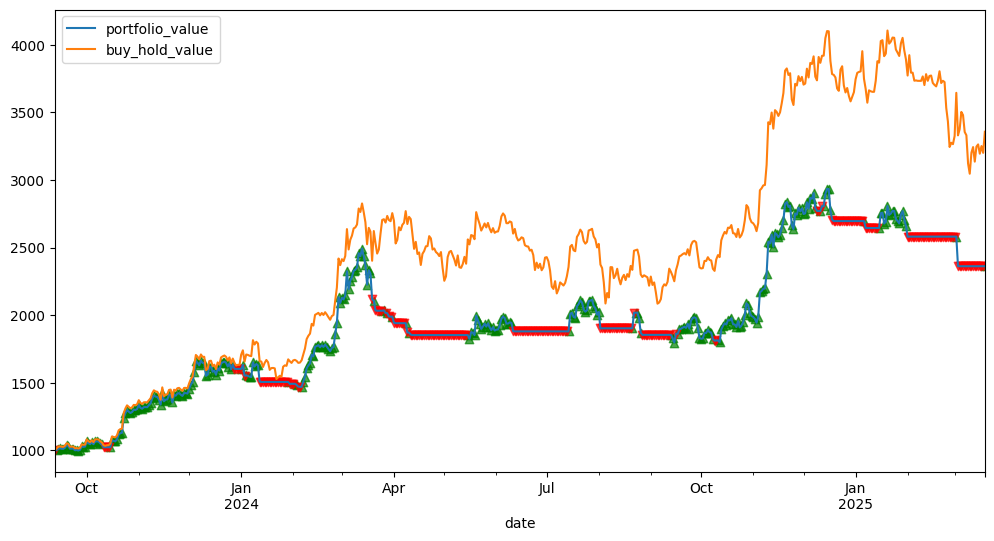

In [6]:

import matplotlib.pyplot as plt
# Create a figure and axis for better control
fig, ax = plt.subplots(figsize=(12, 6))

# Plot portfolio value and buy & hold value
portfolio[['portfolio_value', 'buy_hold_value']].plot(ax=ax)

# Add markers for different regimes
bullish_points = portfolio[portfolio['regime'] == 'Bullish'].index
bearish_points = portfolio[portfolio['regime'] == 'Bearish'].index
other_points = portfolio[portfolio['regime'] == 'Other'].index

# Plot markers for each regime type
ax.scatter(bullish_points, portfolio.loc[bullish_points, 'portfolio_value'], 
           color='green', marker='^', label='Bullish', alpha=0.7)
ax.scatter(bearish_points, portfolio.loc[bearish_points, 'portfolio_value'], 
           color='red', marker='v', label='Bearish', alpha=0.7)
ax.scatter(other_points, portfolio.loc[other_points, 'portfolio_value'], 
           color='blue', marker='o', label='Other', alpha=0.7, s=20)

# Add legend and labels
ax.set_title('Portfolio Performance with Regime Markers')
ax.set_xlabel('Date')
ax.set_ylabel('Value')
ax.legend()

plt.tight_layout()

In [7]:
portfolio['trading_state'].value_counts()

trading_state
1    349
0    206
Name: count, dtype: int64

### 3.2 Performance Metrics
The `metrics` dictionary contains financial performance metrics for the strategy and buy-and-hold benchmark, including annual returns, volatility, Sharpe ratio, Sortino ratio, max drawdown, information ratio, and more.

In [7]:
# Inspect performance metrics
print("Performance Metrics:")
for key, value in metrics.items():
    print(f"{key}: {value:.4f}")

Performance Metrics:
BTC Annual Return: 1.5193
Strategy Annual Return: 0.8945
BTC Volatility: 0.5056
Strategy Volatility: 0.3843
BTC Sharpe Ratio: 3.0049
Strategy Sharpe Ratio: 2.3273
BTC Sortino Ratio: 4.8135
Strategy Sortino Ratio: 2.9198
BTC Max Drawdown: -0.2623
Strategy Max Drawdown: -0.2787
Information Ratio: -1.8899
Number of Trades: 50.0000
Total Trading Costs: 50.0000
Final Buy & Hold Value: 3.3562
Final Strategy Value: 2.3614
Outperformance: -0.9948


### 3.3 MCC Scores
The `mcc_scores` dictionary contains Matthews Correlation Coefficient (MCC) scores for each regime class (`Bullish`, `Bearish`, `Other`) and the average MCC for `Bullish` and `Bearish`. This evaluates the classification performance of the Random Forest model.

In [9]:
# Inspect MCC scores
print("MCC Scores:")
for key, value in mcc_scores.items():
    print(f"{key}: {value:.4f}")

MCC Scores:
Bearish: 0.4633
Bullish: 0.6771
Other: 0.0130
Avg Bullish & Bearish: 0.5702


## 4. Save the Model

We save the trained model to a file for future use. This allows you to reload the model later without retraining.

In [10]:
# Save the model
#kmrf.save_model('kmrf_model_test.pkl')